In [ ]:
import polars as pl
import seaborn as sns
import torch
from model.model import featurize_smiles, load_model
from torch import nn

model = load_model("model/model.safetensors")  # MLP in eval mode

In [3]:
bromides = pl.read_csv("../../data/glorius-bromides.csv")
smis = bromides["SMILES"].to_list()

In [4]:
X = featurize_smiles(smis)  # (n, 2048) ECFP4 features
logits = model(X)  # (n, 2): [class 0, class 1]
probs = logits.softmax(-1)  # (n, 2): [prob(class 0), prob(class 1)]
print(probs)

tensor([[0.0602, 0.0490, 0.3386, 0.5522],
        [0.1101, 0.0807, 0.3206, 0.4887],
        [0.0507, 0.0416, 0.2477, 0.6600],
        ...,
        [0.2528, 0.0778, 0.0309, 0.6384],
        [0.0081, 0.0209, 0.0110, 0.9600],
        [0.2758, 0.0039, 0.0748, 0.6454]], grad_fn=<SoftmaxBackward0>)


In [5]:
# ============================================================================
# Precomputation
# ============================================================================


@torch.no_grad()
def precompute_population_stats(
    model: nn.Module,
    population_smiles: list[str],
    gamma: float = 2.0,
) -> dict[str, torch.Tensor | dict[int, float]]:
    """Compute population statistics needed for scoring.

    Uses the target model's own predictions as pseudo-labels.

    Parameters
    ----------
    model : nn.Module
        Target multi-class classifier, returns (B, C) logits.
    population_smiles : list[str]
        Pool of SMILES representing the broader chemical space.
    gamma : float
        Pairwise LR threshold (not used here, stored for downstream).

    Returns
    -------
    stats : dict
        Contains:
        - "pop_confs": Tensor (N,) — target model confidence on its
          predicted class for each population molecule.
        - "class_mean": dict[int, float] — mean logit margin per class.
        - "class_std": dict[int, float] — std logit margin per class.
        - "gamma": float — stored threshold.

    """
    fps = featurize_smiles(population_smiles)
    logits = model(fps)  # (N, C)
    probs = logits.softmax(dim=-1)
    pred_classes = probs.argmax(dim=-1)

    # Confidence on predicted (pseudo) label
    pop_confs = probs.gather(1, pred_classes.unsqueeze(1)).squeeze(1)

    # Top-1 minus top-2 margin
    top2 = logits.topk(2, dim=-1).values
    margins = top2[:, 0] - top2[:, 1]

    # Per-class margin statistics for z-score calibration
    class_mean: dict[int, float] = {}
    class_std: dict[int, float] = {}
    for c in pred_classes.unique().tolist():
        mask = pred_classes == c
        class_mean[c] = margins[mask].mean().item()
        class_std[c] = margins[mask].std().item() + 1e-6

    return {
        "pop_confs": pop_confs,
        "class_mean": class_mean,
        "class_std": class_std,
        "gamma": gamma,
    }


# ============================================================================
# Scoring
# ============================================================================


@torch.no_grad()
def score_smiles(
    model: nn.Module,
    smiles_batch: list[str],
    pop_stats: dict,
    margin_weight: float = 0.5,
    invalid_penalty: float = -1.0,
) -> torch.Tensor:
    """Compute membership-inference reward for generated SMILES.

    Parameters
    ----------
    model : nn.Module
        Target multi-class classifier, returns (B, C) logits.
    smiles_batch : list[str]
        Generated SMILES from the RL agent.
    pop_stats : dict
        Output of ``precompute_population_stats``.
    margin_weight : float
        Blend between calibrated margin (1.0) and pairwise signal (0.0).
    invalid_penalty : float
        Score assigned to unparseable SMILES.

    Returns
    -------
    rewards : torch.Tensor
        Shape (len(smiles_batch),). Higher = more likely a member.

    """
    rewards = torch.full((len(smiles_batch),), invalid_penalty)

    # Featurise valid molecules
    valid_smi, valid_idx = [], []
    for i, smi in enumerate(smiles_batch):
        fp = featurize_smiles([smi])
        if fp is not None and fp.shape[0] > 0:
            valid_smi.append(smi)
            valid_idx.append(i)

    if not valid_smi:
        return rewards

    fps = featurize_smiles(valid_smi)
    logits = model(fps)  # (B, C)
    probs = logits.softmax(dim=-1)
    pred_classes = probs.argmax(dim=-1)
    conf_x = probs.gather(1, pred_classes.unsqueeze(1)).squeeze(1)  # (B,)

    # --- Signal 1: calibrated margin ---
    top2 = logits.topk(2, dim=-1).values
    margins = top2[:, 0] - top2[:, 1]  # (B,)

    class_mean = pop_stats["class_mean"]
    class_std = pop_stats["class_std"]

    z_scores = torch.zeros_like(margins)
    for i, c in enumerate(pred_classes.tolist()):
        mu = class_mean.get(c, 0.0)
        sigma = class_std.get(c, 1.0)
        z_scores[i] = (margins[i] - mu) / sigma

    calibrated = torch.sigmoid(z_scores)  # (B,)

    # --- Signal 2: pairwise confidence ratio ---
    pop_confs = pop_stats["pop_confs"]  # (N,)
    gamma = pop_stats["gamma"]

    # (B, 1) / (1, N) -> (B, N)
    lr = conf_x.unsqueeze(1) / (pop_confs.unsqueeze(0) + 1e-10)
    pairwise = (lr >= gamma).float().mean(dim=1)  # (B,)

    # --- Blend ---
    scores = margin_weight * calibrated + (1.0 - margin_weight) * pairwise

    rewards[valid_idx] = scores
    return rewards

In [17]:
margin_weight=0.5

pop_stats = precompute_population_stats(model, smis, gamma=2.0)
scores = score_smiles(model, smis, pop_stats, margin_weight=margin_weight)

<Axes: ylabel='Count'>

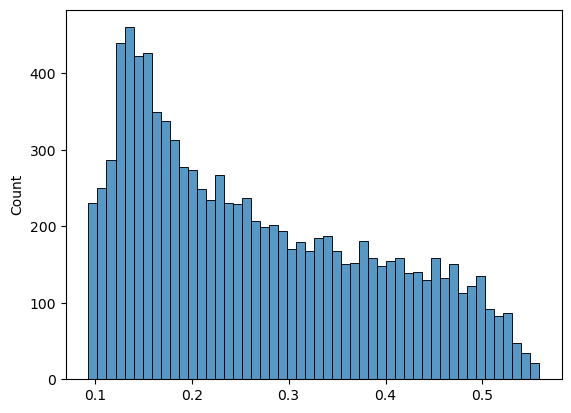

In [18]:
sns.histplot(scores.detach().cpu().numpy(), bins=50)

In [20]:
smi_to_score = pl.DataFrame(
    {
        "SMILES": smis,
        "Score": scores.detach().squeeze().cpu().numpy(),
    },
)

top_scores = smi_to_score.sort("Score", descending=True).head(10)
top_scores.show()

SMILES,Score
str,f32
"""CCN1C(=O)c2cccc3c(NS(=O)(=O)c4…",0.558819
"""Nc1ccc(OCc2cccc(F)c2)c(Br)c1""",0.557253
"""FC(F)C(F)(F)Oc1cccc(CNc2cccc(B…",0.556503
"""COc1cc2oc(-c3ccc(Br)cc3)cc(=O)…",0.556125
"""N#Cc1ccc(CNc2cccc(Br)c2)c(F)c1""",0.556053


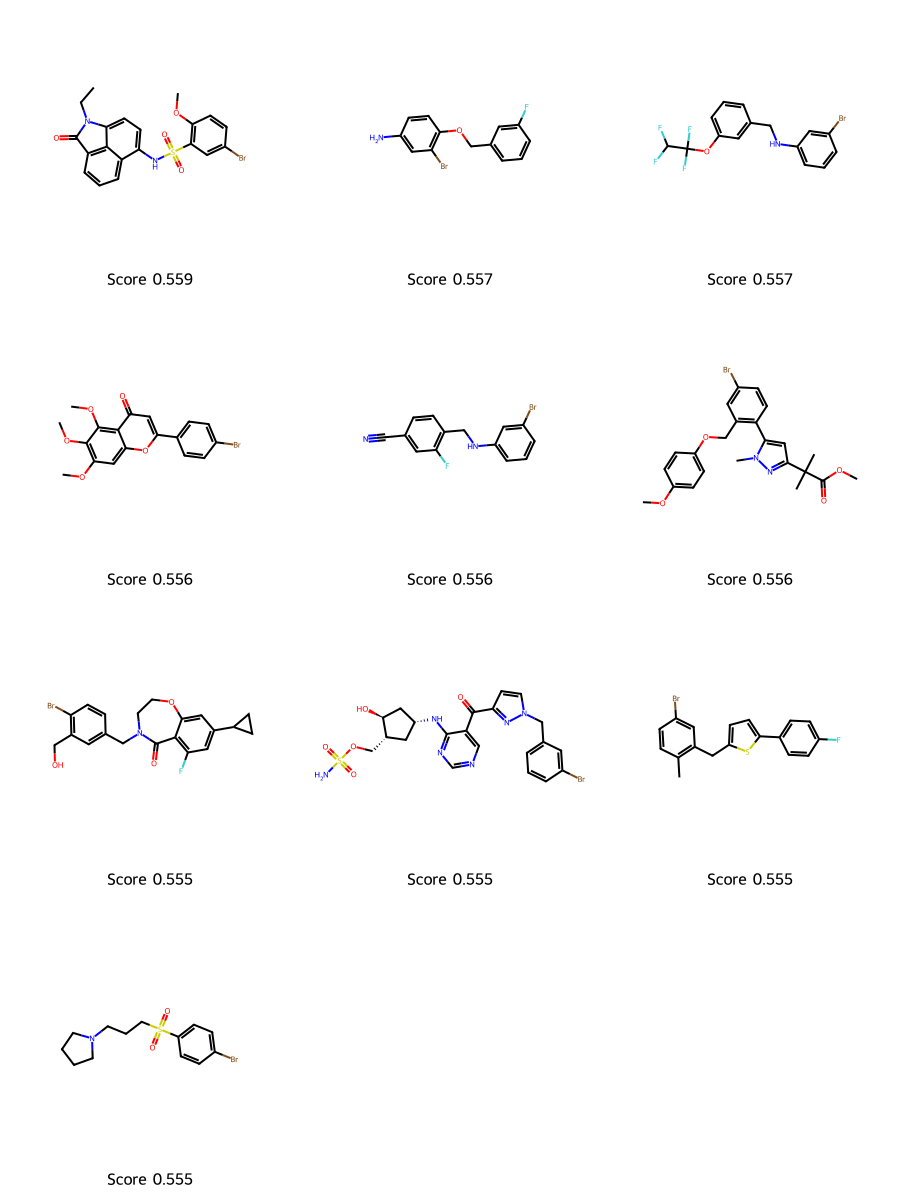

In [21]:
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.Draw import MolsToGridImage

mols = [MolFromSmiles(smi) for smi in top_scores["SMILES"]]
MolsToGridImage(
    mols,
    legends=[f"Score {score:.3f}" for score in top_scores["Score"]],
    molsPerRow=3,
    useSVG=True,
    subImgSize=(300, 300),
)

In [ ]:
submission = smi_to_score.sort("Score", descending=True).head(1000)
submission

SMILES,Score
str,f32
"""CN(C)CCOc1cc(Br)c(F)cc1[N+](=O…",0.999999
"""Brc1ccc(/N=C/c2ccco2)cc1""",0.999996
"""COC(=O)c1ccc(Br)c(CCN)c1""",0.999989
"""N[C@@H](CCC(=O)N[C@@H](CSCc1cc…",0.999988
"""Nc1ccc(Br)c(O)c1C(=O)O""",0.999985
…,…
"""Cc1cc([N+](=O)[O-])c(Br)cc1F""",0.946715
"""CNC(=O)c1ccccc1Br""",0.946423
"""O=Cc1cc(Br)cc(Cl)c1F""",0.94618


In [ ]:
submission.select("SMILES").write_csv("submission.csv")